In [1]:
# import warnings is simply used to remove warnings about incompatibility with future Pandas update on Nate's device
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
from ET_func_run_all_functions import *
import pandas as pd
from ipynb.fs.defs.ET_working_file import (construct_calendar_year_list, 
                                            construct_business_case_year_list, 
                                            construct_operations_years_list, 
                                            construct_decomissioning_years_list, 
                                            construction_phase,
                                            operational_phase,
                                            total_capex,
                                            decommissioning_phase,
                                            taxes_and_profits_part1,
                                            debt_and_loan_part1,
                                            taxes_and_profits_part2,
                                            debt_and_loan_part2,
                                            project_reserves,
                                            equity_funding,
                                            present_value_cashflows,
                                            cumulative_equity_and_debt_cashflows,
                                            discounted_cashflows_for_levelized_cost,
                                            levelized_cost_and_revenues,
                                            project_kpi,
                                            equity_kpi,
                                            output_kpi)
from ET_input_data import *
import importlib
import ET_input_data
from NSE_get_data_from_ESDL import *


[[622430. 622430. 622430.]
 [622430. 622430. 622430.]
 [622430. 622430. 622430.]]
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl


In [3]:
file_names = ["TNVDW_cost_single_units_v1_pessimistic_scenario.esdl", "TNVDW_cost_single_units_v1_most_likely_scenario.esdl", "TNVDW_cost_single_units_v1_optimistic_scenario.esdl"]

# make a dataframe that will contain the levelized costs and revenues from all scenarios    
# Define the levels of the MultiIndex
groups = ['Pessimistic', 'Most likely', 'Optimistic']  # Group names
sub_columns = ['Costs', 'Revenues']  # Sub-column names

# Create the MultiIndex from the groups and sub_columns
multi_index = pd.MultiIndex.from_product([groups, sub_columns], names=['Scenario', 'Type'])

# Create an empty DataFrame with the multi-level columns
df_lcr_all_scenarios = pd.DataFrame(columns=multi_index)

# Make a dataframe that will contain all kpi results
df_kpi_results = pd.DataFrame(columns=['Pessimistic', 'Most likely', 'Optimistic', 'Unit'])


for x in file_names:

    esh = EnergySystemHandler()
    esh.load_file(x)
    energy_system = esh.get_energy_system()
    instance_list = energy_system.instance
    my_instance = instance_list[0]

    if x == file_names[0]:
        drop_scenarios = ['most_likely','optimistic']
    elif x == file_names[1]:
        drop_scenarios = ['pessimistic','optimistic']
    else: 
        drop_scenarios = ['pessimistic','most_likely']

    save_to_pickle(drop_scenarios, asset_parameters)

    importlib.reload(ET_input_data)

    ET_tot_capex = total_capex(ET_input_data.platform_capex, 
                               ET_input_data.substation_capex, 
                               ET_input_data.cable_capex_km,
                               ET_input_data.cable_distance)

    ET_run_all_functions(ET_tot_capex,
                         ET_input_data.platform_capex, 
                         ET_input_data.substation_capex, 
                         ET_input_data.cable_capex_km,
                         ET_input_data.df_ET_opex,
                         ET_input_data.ET_inflation,
                         ET_input_data.df_ET_revenue_transport, 
                         ET_input_data.df_ET_revenues_connections,
                         ET_input_data.ET_decomissioning_percentage,
                         ET_input_data.ET_loan_percentage,
                         ET_input_data.ET_loan_interest_rate,
                         ET_input_data.ET_income_tax_rate,
                         ET_input_data.ET_general_WACC,
                         ET_input_data.ET_lifetime,
                         ET_input_data.cable_distance)
    
    print(ET_tot_capex)

    levelized_cost = levelized_cost_and_revenues(ET_tot_capex,
                                                ET_input_data.platform_capex, 
                                                ET_input_data.substation_capex, 
                                                ET_input_data.cable_capex_km,
                                                ET_input_data.df_ET_opex,
                                                ET_input_data.ET_inflation,
                                                ET_input_data.df_ET_revenue_transport, 
                                                ET_input_data.df_ET_revenues_connections,
                                                ET_input_data.ET_decomissioning_percentage,
                                                ET_input_data.ET_loan_percentage,
                                                ET_input_data.ET_loan_interest_rate,
                                                ET_input_data.ET_income_tax_rate,
                                                ET_input_data.ET_general_WACC,
                                                ET_input_data.ET_lifetime,
                                                ET_input_data.cable_distance)
    

    project_result = project_kpi(ET_tot_capex,
                                 ET_input_data.platform_capex, 
                                 ET_input_data.substation_capex, 
                                 ET_input_data.cable_capex_km,
                                 ET_input_data.df_ET_opex,
                                 ET_input_data.ET_inflation,
                                 ET_input_data.df_ET_revenue_transport, 
                                 ET_input_data.df_ET_revenues_connections,
                                 ET_input_data.ET_decomissioning_percentage,
                                 ET_input_data.ET_loan_percentage,
                                 ET_input_data.ET_loan_interest_rate,
                                 ET_input_data.ET_income_tax_rate,
                                 ET_input_data.ET_general_WACC,
                                 ET_input_data.ET_lifetime,
                                 ET_input_data.cable_distance)

    equity_result = equity_kpi(ET_tot_capex,
                               ET_input_data.platform_capex, 
                               ET_input_data.substation_capex, 
                               ET_input_data.cable_capex_km,
                               ET_input_data.df_ET_opex,
                               ET_input_data.ET_inflation,
                               ET_input_data.df_ET_revenue_transport, 
                               ET_input_data.df_ET_revenues_connections,
                               ET_input_data.ET_decomissioning_percentage,
                               ET_input_data.ET_loan_percentage,
                               ET_input_data.ET_loan_interest_rate,
                               ET_input_data.ET_income_tax_rate,
                               ET_input_data.ET_general_WACC,
                               ET_input_data.ET_lifetime,
                               ET_input_data.cable_distance)

    output_result = output_kpi(ET_tot_capex,
                               ET_input_data.platform_capex, 
                               ET_input_data.substation_capex, 
                               ET_input_data.cable_capex_km,
                               ET_input_data.df_ET_opex,
                               ET_input_data.ET_inflation,
                               ET_input_data.df_ET_revenue_transport, 
                               ET_input_data.df_ET_revenues_connections,
                               ET_input_data.ET_decomissioning_percentage,
                               ET_input_data.ET_loan_percentage,
                               ET_input_data.ET_loan_interest_rate,
                               ET_input_data.ET_income_tax_rate,
                               ET_input_data.ET_general_WACC,
                               ET_input_data.ET_lifetime,
                               ET_input_data.cable_distance)



    # create a temporary column of dummy data at the top-level of the MultiIndex (which will later be dropped)
    # without first creating this temporary column, pandas will not be able to assign values to the MultiIndex df
    df_lcr_all_scenarios.loc[:, 'temp'] = levelized_cost['cost']


    if x == file_names[0]:
        # add to pessimistic
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Revenues')] = levelized_cost['revenues'] 

        project_result_pes = project_result.drop(columns=['Unit'])
        project_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        equity_result_pes = equity_result.drop(columns=['Unit'])
        equity_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        output_result_pes = output_result.drop(columns=['Unit'])
        output_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)

    elif x == file_names[1]:
        # add to most_likely
        df_lcr_all_scenarios.loc[:, ('Most likely','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Most likely','Revenues')] = levelized_cost['revenues']

        project_result_ml = project_result.drop(columns=['Unit'])
        project_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        equity_result_ml = equity_result.drop(columns=['Unit'])
        equity_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        output_result_ml = output_result.drop(columns=['Unit'])
        output_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)

    else: 
        # add to optimistic
        df_lcr_all_scenarios.loc[:, ('Optimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Optimistic','Revenues')] = levelized_cost['revenues']

        project_result_opt = project_result
        project_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        equity_result_opt = equity_result
        equity_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        output_result_opt = output_result
        output_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)

df_project_kpi_results = pd.concat([project_result_pes, project_result_ml, project_result_opt], axis=1)
df_equity_kpi_results = pd.concat([equity_result_pes, equity_result_ml, equity_result_opt], axis=1)
df_output_kpi_results = pd.concat([output_result_pes, output_result_ml, output_result_opt], axis=1)

project_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Project KPI's"])
equity_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Equity KPI's"])
output_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Output KPI's"])

df_project_kpi_results = pd.concat([project_kpi_row, df_project_kpi_results], axis=0)
df_equity_kpi_results = pd.concat([equity_kpi_row, df_equity_kpi_results], axis=0)
df_output_kpi_results = pd.concat([output_kpi_row, df_output_kpi_results], axis=0)

df_kpi_results = pd.concat([df_project_kpi_results, df_equity_kpi_results, df_output_kpi_results], axis=0)

        
# drop temporary column that was only used for correct multi-level dataframe assignment        
df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')

df_lcr_all_scenarios

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
[[622430. 622430. 622430.]
 [622430. 622430. 622430.]
 [622430. 622430. 622430.]]
429.82505840000005
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
[[622430. 622430. 622430.]
 [622430. 622430. 622430.]
 [622430. 622430. 622430.]]
214.91252920000002
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
[[622430. 622430. 622430.]
 [622430. 622430. 622430.]
 [622430. 622430. 622430.]]
214.91252920000002


C:\Users\DinaBoer\AppData\Local\Temp\ipykernel_5064\1916745372.py:184: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')


Scenario                    Pessimistic            Most likely             \
Type                              Costs   Revenues       Costs   Revenues   
platforms_capex               10.087693        0.0    4.642707        0.0   
substations_capex             21.971301        0.0   10.111956        0.0   
cables_capex                   9.001074        0.0    4.142607        0.0   
opex_cables                    3.448474        0.0    1.744485        0.0   
opex_platform_substation       12.28238        0.0    6.213307        0.0   
decommissioning                0.606764        0.0    0.344167        0.0   
interest_costs                15.595809        0.0     4.62268        0.0   
contingency                    2.042871        0.0    0.893239        0.0   
tax_expenses                       -0.0        0.0        -0.0        0.0   
revenues_connection_tariffs        -0.0        0.0        -0.0        0.0   
revenues_transport_tariffs         -0.0        0.0        -0.0        0.0   
profits                             0.0        0.0         0.0        0.0   
unprofitable_gap                    0.0  75.036365         0.0  32.715148   

Scenario                    Optimistic             
Type                             Costs   Revenues  
platforms_capex               4.260268        0.0  
substations_capex             9.278992        0.0  
cables_capex                  3.801363        0.0  
opex_cables                    1.76552        0.0  
opex_platform_substation      6.288226        0.0  
decommissioning               0.389606        0.0  
interest_costs                2.529373        0.0  
contingency                   0.769546        0.0  
tax_expenses                      -0.0        0.0  
revenues_connection_tariffs       -0.0        0.0  
revenues_transport_tariffs        -0.0        0.0  
profits                            0.0        0.0  
unprofitable_gap                   0.0  29.082895

All KPI results

In [4]:
def clean_index_name(index):
    index = index.replace("_", " ")  # Replace underscores with spaces
    index = index.capitalize()  # Capitalize the first letter
    index = index.replace("kpi's", "KPI's")
    index = index.replace("EUR", "€")
    return index

# Apply the function to each index name
new_index_names = {index: clean_index_name(index) for index in df_kpi_results.index}

# Rename the index using the dictionary
df_kpi_results.rename(index=new_index_names, inplace=True)

# Change EUR to €
df_kpi_results['Unit'] = df_kpi_results['Unit'].replace({'Eur/MWh': '€/MWh', 'MEUR': '€'})

# Display the cleaned-up DataFrame
df_kpi_results.style.format(precision=2)


,Pessimistic,Most likely,Optimistic,Unit
Project KPI's,,,,
Net present value,-527.54,-275.41,-288.56,€
Internal rate of return,nan,nan,nan,%
Return on investment,-276.56,-241.83,-223.19,%
Payback period,-14.46,-16.54,-17.92,years
Discounted return on investment,-138.31,-142.11,-146.44,%
Discounted payback period,-104.41,-94.99,-86.12,years
Equity KPI's,,,,
Net present value,-504.05,-257.83,-266.11,€
Internal rate of return,nan,nan,nan,%


In [5]:
# This can be used to copy the dataframe into Excel

df_kpi_results.to_clipboard()

Clean up column names to improve visualisation in the graph

In [6]:
# transpose dataframe to prepare for plotting
t_df_lcr_all_scenarios = df_lcr_all_scenarios.T

def clean_column_name(col):
    col = col.replace("_", " ")  # Replace underscores with spaces
    col = col.capitalize()  # Capitalize the first letter
    col = col.replace("Capex", "CAPEX")
    col = col.replace("capex", "CAPEX")
    col = col.replace("Opex", "OPEX")
    col = col.replace("ppa", "PPA")
    col = col.replace("platform substation", "platform + substation")
    return col

# Apply the function to each column name
new_column_names = {col: clean_column_name(col) for col in t_df_lcr_all_scenarios.columns}

# Rename the columns using the dictionary
t_df_lcr_all_scenarios.rename(columns=new_column_names, inplace=True)

t_df_lcr_all_scenarios

Platforms CAPEX Substations CAPEX Cables CAPEX  \
Scenario    Type                                                      
Pessimistic Costs          10.087693         21.971301     9.001074   
            Revenues             0.0               0.0          0.0   
Most likely Costs           4.642707         10.111956     4.142607   
            Revenues             0.0               0.0          0.0   
Optimistic  Costs           4.260268          9.278992     3.801363   
            Revenues             0.0               0.0          0.0   

                     OPEX cables OPEX platform + substation Decommissioning  \
Scenario    Type                                                              
Pessimistic Costs       3.448474                   12.28238        0.606764   
            Revenues         0.0                        0.0             0.0   
Most likely Costs       1.744485                   6.213307        0.344167   
            Revenues         0.0                        0.0             0.0   
Optimistic  Costs        1.76552                   6.288226        0.389606   
            Revenues         0.0                        0.0             0.0   

                     Interest costs Contingency Tax expenses  \
Scenario    Type                                               
Pessimistic Costs         15.595809    2.042871         -0.0   
            Revenues            0.0         0.0          0.0   
Most likely Costs           4.62268    0.893239         -0.0   
            Revenues            0.0         0.0          0.0   
Optimistic  Costs          2.529373    0.769546         -0.0   
            Revenues            0.0         0.0          0.0   

                     Revenues connection tariffs Revenues transport tariffs  \
Scenario    Type                                                              
Pessimistic Costs                           -0.0                       -0.0   
            Revenues                         0.0                        0.0   
Most likely Costs                           -0.0                       -0.0   
            Revenues                         0.0                        0.0   
Optimistic  Costs                           -0.0                       -0.0   
            Revenues                         0.0                        0.0   

                     Profits Unprofitable gap  
Scenario    Type                               
Pessimistic Costs        0.0              0.0  
            Revenues     0.0        75.036365  
Most likely Costs        0.0              0.0  
            Revenues     0.0        32.715148  
Optimistic  Costs        0.0              0.0  
            Revenues     0.0        29.082895

Make graph

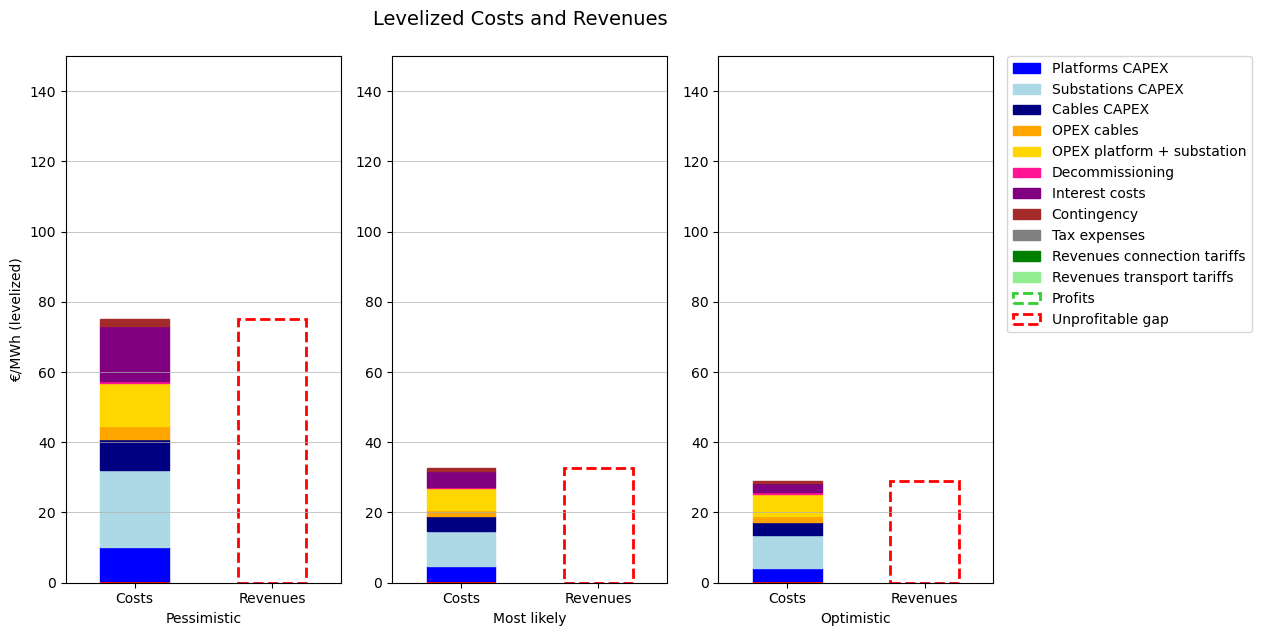

In [7]:
import matplotlib.pyplot as plt

# Define specific colors for each variable
color_mapping = {
    'Platforms CAPEX': 'blue',
    'Substations CAPEX': 'lightblue',
    'Cables CAPEX': 'navy',
    'OPEX cables': 'orange',
    'OPEX platform + substation': 'gold',
    'Decommissioning': '#FF1493',
    'Interest costs': 'purple',
    'Contingency': 'brown',
    'Tax expenses': 'grey',
    'Revenues connection tariffs': 'green',
    'Revenues transport tariffs': 'lightgreen',
    'Profits': 'limegreen',
    'Unprofitable gap': 'red'  
}

# Plot levelized costs and revenues
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# plt.suptitle('Levelized Costs and Revenues')

# List of axes
axes = [ax1, ax2, ax3]

# Get column names
column_names = t_df_lcr_all_scenarios.columns

# Plot each scenario and apply custom colors
for ax, scenario in zip(axes, ['Pessimistic', 'Most likely', 'Optimistic']):
    plot = t_df_lcr_all_scenarios.loc[scenario].plot(
        kind='bar', stacked=True, ax=ax, rot='horizontal', legend=False,
        xlabel=scenario, ylabel='€/MWh (levelized)' if ax == ax1 else None
    )
    
    # Iterate through bars and assign colors based on the variable name
    for i, bar in enumerate(ax.containers):
        for patch in bar:
            col_name = column_names[i]  # Get the corresponding column name
            
            if col_name == 'Unprofitable gap':  # Apply dashed line for 'Unprofitable gap'
                patch.set_edgecolor('red')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            elif col_name == "Profits":
                patch.set_edgecolor('limegreen')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            else:
                # Use the color mapping for other variables
                patch.set_color(color_mapping.get(col_name, 'gray'))  # Default to gray if not found

# Add a custom title above the "Most likely" plot
fig.text(0.35, 1.02, 'Levelized Costs and Revenues', ha='center', va='bottom', fontsize=14)


# Add a single legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Apply grid and y-limit to all axes
for ax in axes:
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5)
    ax.set_ylim(0, 150)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend
plt.show()


In [8]:
df = t_df_lcr_all_scenarios.loc[t_df_lcr_all_scenarios.index.get_level_values('Type') != 'Revenues']
df = df.drop(['Unprofitable gap', 'Revenues transport tariffs', 'Revenues connection tariffs'], axis=1)
df = df.drop(['Profits'], axis = 1)

In [9]:
df

,,Platforms CAPEX,Substations CAPEX,Cables CAPEX,OPEX cables,OPEX platform + substation,Decommissioning,Interest costs,Contingency,Tax expenses
Scenario,Type,,,,,,,,,
Pessimistic,Costs,10.087693,21.971301,9.001074,3.448474,12.28238,0.606764,15.595809,2.042871,-0.0
Most likely,Costs,4.642707,10.111956,4.142607,1.744485,6.213307,0.344167,4.62268,0.893239,-0.0
Optimistic,Costs,4.260268,9.278992,3.801363,1.76552,6.288226,0.389606,2.529373,0.769546,-0.0


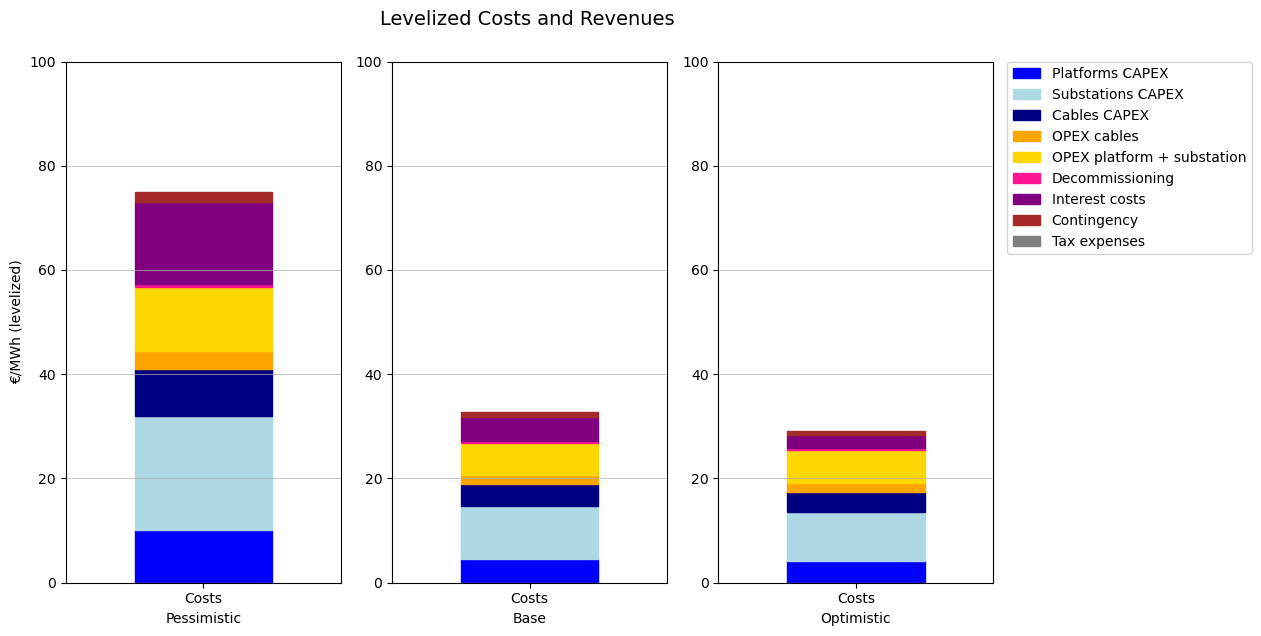

In [10]:
import matplotlib.pyplot as plt

# Define specific colors for each variable
color_mapping = {
    'Platforms CAPEX': 'blue',
    'Substations CAPEX': 'lightblue',
    'Cables CAPEX': 'navy',
    'OPEX cables': 'orange',
    'OPEX platform + substation': 'gold',
    'Decommissioning': '#FF1493',
    'Interest costs': 'purple',
    'Contingency': 'brown',
    'Tax expenses': 'grey',
    'Revenues connection tariffs': 'green',
    'Revenues transport tariffs': 'lightgreen',
    'Profits': 'limegreen',
    'Unprofitable gap': 'red'  
}

# Plot levelized costs and revenues
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# plt.suptitle('Levelized Costs and Revenues')

# List of axes
axes = [ax1, ax2, ax3]

# Get column names
column_names = df

# Plot each scenario and apply custom colors
for ax, scenario in zip(axes, ['Pessimistic', 'Most likely', 'Optimistic']):
    xlabel = 'Base' if scenario == 'Most likely' else scenario
    plot = df.loc[scenario].plot(
        kind='bar', stacked=True, ax=ax, rot='horizontal', legend=False,
        xlabel=xlabel, ylabel='€/MWh (levelized)' if ax == ax1 else None
    )
    
    # Iterate through bars and assign colors based on the variable name
    for i, (patches, col_name) in enumerate(zip(ax.containers, column_names)):  
        for patch in patches:  
            if col_name == 'Unprofitable gap':  
                patch.set_edgecolor('red')  
                patch.set_linestyle('--')    
                patch.set_linewidth(2)      
                patch.set_facecolor('white')  
            elif col_name == "Profits":  
                patch.set_edgecolor('limegreen')  
                patch.set_linestyle('--')    
                patch.set_linewidth(2)      
                patch.set_facecolor('white')  
            else:  
                patch.set_color(color_mapping.get(col_name, 'gray'))  

# Add a custom title above the "Most likely" plot
fig.text(0.355, 1.02, 'Levelized Costs and Revenues', ha='center', va='bottom', fontsize=14)


# Add a single legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Apply grid and y-limit to all axes
for ax in axes:
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5)
    ax.set_ylim(0, 100)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend
plt.show()


In [11]:
df = df.drop(['Tax expenses'], axis=1)

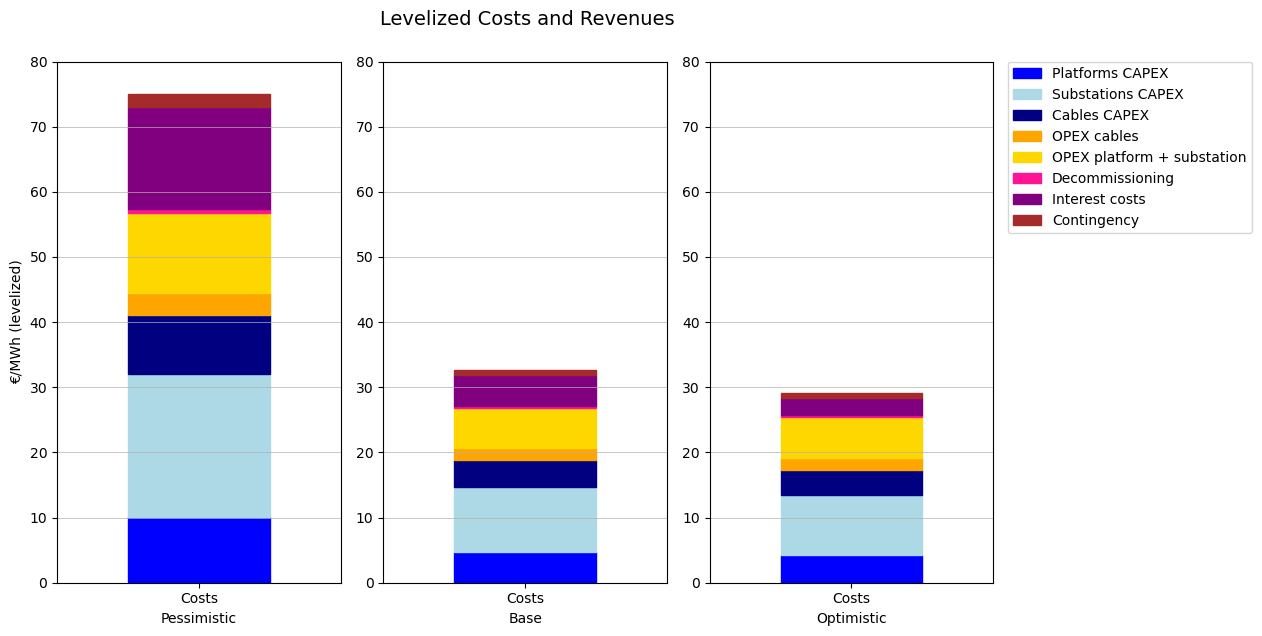

In [14]:
import matplotlib.pyplot as plt

# Define specific colors for each variable
color_mapping = {
    'Platforms CAPEX': 'blue',
    'Substations CAPEX': 'lightblue',
    'Cables CAPEX': 'navy',
    'OPEX cables': 'orange',
    'OPEX platform + substation': 'gold',
    'Decommissioning': '#FF1493',
    'Interest costs': 'purple',
    'Contingency': 'brown',
    'Tax expenses': 'grey',
    'Revenues connection tariffs': 'green',
    'Revenues transport tariffs': 'lightgreen',
    'Profits': 'limegreen',
    'Unprofitable gap': 'red'  
}

# Plot levelized costs and revenues
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# plt.suptitle('Levelized Costs and Revenues')

# List of axes
axes = [ax1, ax2, ax3]

# Get column names
column_names = df

# Plot each scenario and apply custom colors
for ax, scenario in zip(axes, ['Pessimistic', 'Most likely', 'Optimistic']):
    xlabel = 'Base' if scenario == 'Most likely' else scenario
    plot = df.loc[scenario].plot(
        kind='bar', stacked=True, ax=ax, rot='horizontal', legend=False,
        xlabel=xlabel, ylabel='€/MWh (levelized)' if ax == ax1 else None
    )
    
    # Iterate through bars and assign colors based on the variable name
    for i, (patches, col_name) in enumerate(zip(ax.containers, column_names)):  
        for patch in patches:  
            if col_name == 'Unprofitable gap':  
                patch.set_edgecolor('red')  
                patch.set_linestyle('--')    
                patch.set_linewidth(2)      
                patch.set_facecolor('white')  
            elif col_name == "Profits":  
                patch.set_edgecolor('limegreen')  
                patch.set_linestyle('--')    
                patch.set_linewidth(2)      
                patch.set_facecolor('white')  
            else:  
                patch.set_color(color_mapping.get(col_name, 'gray'))  

# Add a custom title above the "Most likely" plot
fig.text(0.355, 1.02, 'Levelized Costs and Revenues', ha='center', va='bottom', fontsize=14)


# Add a single legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Apply grid and y-limit to all axes
for ax in axes:
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5)
    ax.set_ylim(0, 80)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend
plt.show()
